In [2]:
import sys
import os
base_dir = os.path.dirname(__file__) if '__file__' in globals() else os.getcwd()
sys.path.append(os.path.abspath(os.path.join(base_dir, '..')))
import argparse
from tqdm import tqdm
from torch import optim
from MvDST_gpu import MvDST
from utils import *
import torch.nn.functional as F
import pandas as pd
from utils import get_logger
import scanpy as sc
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.cluster import adjusted_rand_score
# import os
import scipy.sparse as sparse
import anndata
import seaborn as sns
import time
sc.logging.print_header()
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 3
sns.set_style("white")
np.random.seed(0)

scanpy==1.10.3 anndata==0.10.9 umap==0.5.7 numpy==1.23.5 scipy==1.13.1 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.11.8 pynndescent==0.5.13


In [3]:
section_id = 'V1'
input_dir = os.path.join('F:\\王海月\\MvDST\\代码\\UGIMC\\Data\\Breast_Cancer', section_id)
adata = sc.read_visium(path=input_dir, count_file='filtered_feature_bc_matrix.h5')
adata.var_names_make_unique()
sc.pp.calculate_qc_metrics(adata, inplace=True)
adata = adata[:, adata.var['total_counts'] > 100]
cell_type_indeces = np.load(input_dir + '/cell_types.npy')
adata.obs['Ground Truth'] = cell_type_indeces
adata.obs['Ground Truth'] = adata.obs['Ground Truth'].astype('int')
adata.obs['Ground Truth'] = adata.obs['Ground Truth'].astype('category')

reading F:\王海月\MvDST\代码\UGIMC\Data\Breast_Cancer\V1\filtered_feature_bc_matrix.h5
 (0:00:01)


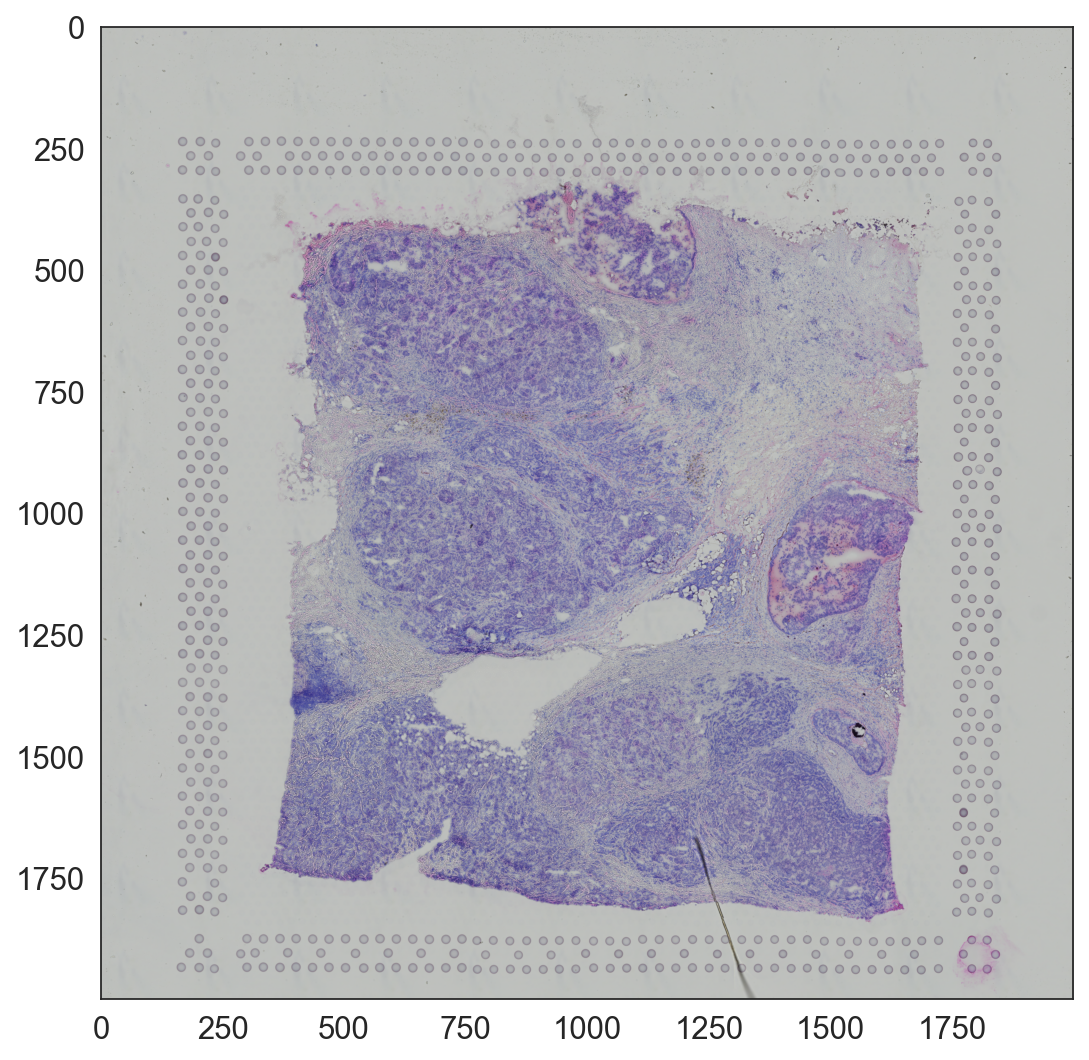

In [4]:
spatial=pd.read_csv("F:\\王海月\\MvDST\\代码\\UGIMC\\Data\\Breast_Cancer\\V1\\spatial\\tissue_positions_list.csv",sep=",",header=None,na_filter=False,index_col=0) 
spatial = spatial[spatial[1] == 1]
adata.obs["x2"]=spatial[2]
adata.obs["x3"]=spatial[3]
adata.obs["x4"]=spatial[4]
adata.obs["x5"]=spatial[5]
img = adata.uns['spatial']['V1_Breast_Cancer_Block_A_Section_1']['images']['hires']
scale_fact = adata.uns['spatial']['V1_Breast_Cancer_Block_A_Section_1']['scalefactors']['tissue_hires_scalef']
plt.imshow(img)

In [5]:
# Set coordinates
adata.obs["x_array"] = adata.obs["x2"]
adata.obs["y_array"] = adata.obs["x3"]
adata.obs["x_pixel"] = adata.obs["x4"] * scale_fact
adata.obs["y_pixel"] = adata.obs["x5"] * scale_fact
x_array = adata.obs["x_array"].tolist()
y_array = adata.obs["y_array"].tolist()
x_pixel = adata.obs["x_pixel"].tolist()
y_pixel = adata.obs["y_pixel"].tolist()

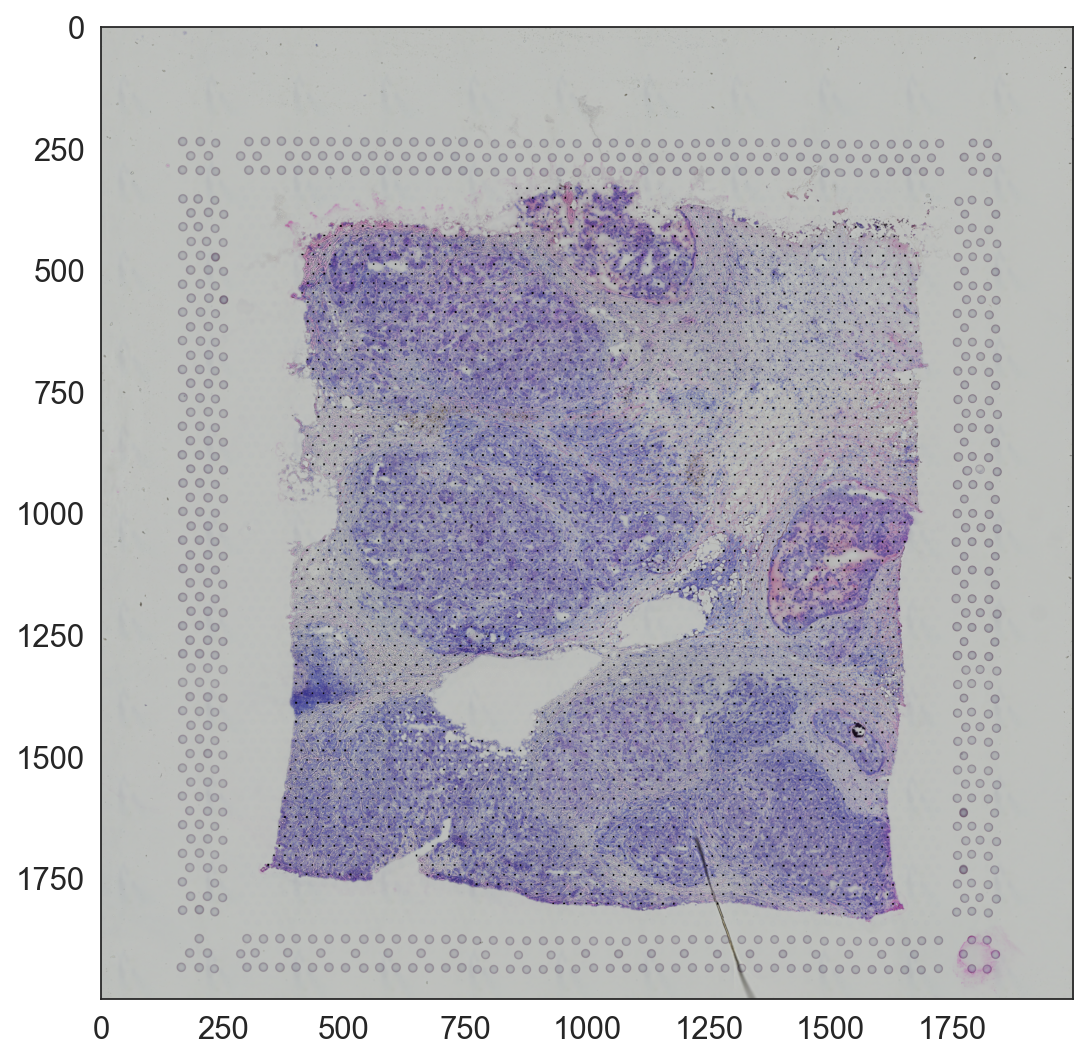

In [6]:
# Test coordinates on the image
img_new = img.copy()
for i in range(len(x_pixel)):
    x = x_pixel[i]
    y = y_pixel[i]
    img_new[int(x - 20 * scale_fact):int(x + 20 * scale_fact), int(y - 20 * scale_fact):int(y + 20 * scale_fact), :] = 0
plt.imshow(img_new)

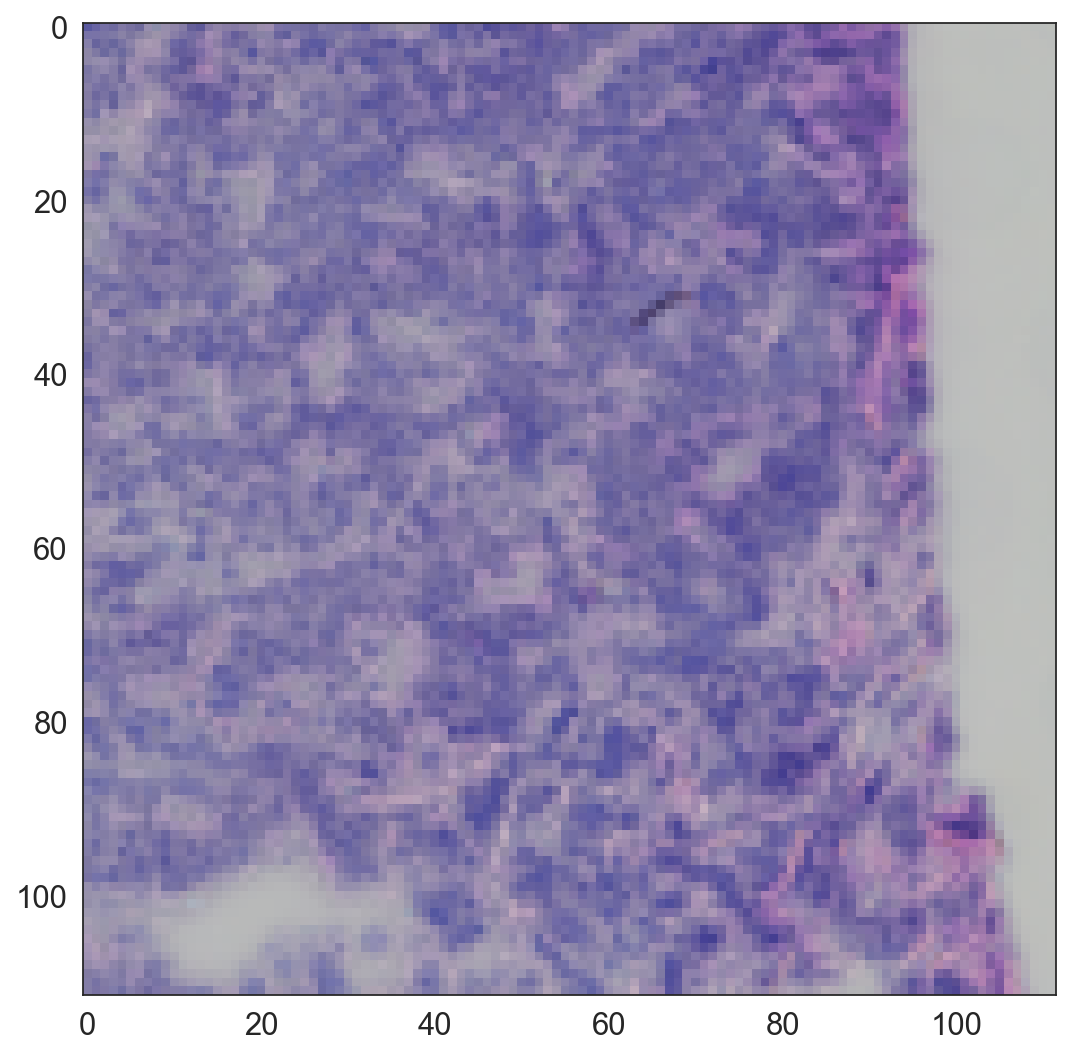

In [7]:
image = adata.uns["spatial"]['V1_Breast_Cancer_Block_A_Section_1']['images']['hires']
scale_factor = adata.uns['spatial']['V1_Breast_Cancer_Block_A_Section_1']['scalefactors']['tissue_hires_scalef']
patches = []
crop_size = 56
for x, y in adata.obsm['spatial'] * scale_factor:
    patches.append(image[int(y - crop_size): int(y + crop_size), int(x - crop_size): int(x + crop_size)])
    
plt.imshow(patches[1000])

In [8]:
# We first crop histology image according to spatial coordinate of spots
from image_feature import image_crop, ImageFeature
from pathlib import Path
import os
save_path = 'results'
save_path_image_crop = Path(os.path.join(save_path, 'image_crop', f'{section_id}'))
save_path_image_crop.mkdir(parents=True, exist_ok=True)
adata = image_crop(adata, save_path=save_path_image_crop, crop_size=56, verbose=False)
adata = ImageFeature(adata, pca_components=200, verbose=True, seeds=2023).extract_image_features()
adata

Tiling Image: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████ [ time left: 00:00 ]
Extract image feature: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████ [ time left: 00:00 ]


The image feature is added to adata.obsm['Image_Feature']
The pca result of image features is added to adata.obsm['image_feat_pca']


AnnData object with n_obs × n_vars = 3798 × 14977
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'Ground Truth', 'x2', 'x3', 'x4', 'x5', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'image_col', 'image_row', 'slice_path'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'spatial', 'image_feature', 'aug_image_feature1', 'aug_image_feature2', 'image_feat_pca'

In [9]:
# # We first crop histology image according to spatial coordinate of spots
# from image_feature import image_crop, ImageFeature
# from pathlib import Path
# import os
# save_path = 'results'
# save_path_image_crop = Path(os.path.join(save_path, 'image_crop', f'{section_id}'))
# save_path_image_crop.mkdir(parents=True, exist_ok=True)
# adata = image_crop(adata, save_path=save_path_image_crop, crop_size=56, verbose=False)

In [10]:
import timm
from timm.layers import SwiGLUPacked
from timm.data.transforms_factory import create_transform
from timm.data import resolve_data_config
from torchvision import transforms
import torch
import os
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"  # 使用国内镜像
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"  # 启用高速传输
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def load_model(model_name, device):
    if model_name == 'UNI':
        model = timm.create_model("hf-hub:MahmoodLab/uni", pretrained=True, init_values=1e-5, dynamic_img_size=True) # PMID:38504018
    elif model_name == 'GIGA':
        model = timm.create_model("hf_hub:prov-gigapath/prov-gigapath", pretrained=True)
    else:
        raise NotImplementedError(f'Model {model_name} not implemented !')
    
    return model.to(device).eval()

uni_model = load_model('UNI', device)
giga_model = load_model('GIGA', device)

In [11]:
uni_transform = create_transform(**resolve_data_config(uni_model.pretrained_cfg, model=uni_model))
giga_transform = transforms.Compose(
    [
        transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ])


In [12]:
from  PIL import Image


uni_model.tag = 'uni'
giga_model.tag = 'giga'

def vis_feature_extract(adata, model, transform, data_frame):
    for spot, slice_path in adata.obs['slice_path'].items():
        spot_slice = Image.open(slice_path).resize((224, 224))
        image = transform(spot_slice).unsqueeze(0).to(device)
        
        with torch.no_grad():
            if model.tag == 'vir':
                feature_emb = model(image)[:, 0]
            else:
                feature_emb = model(image)
            result_npy = feature_emb.data.cpu().numpy().ravel()
            data_frame[spot] = result_npy
        pbar.update(1)

In [13]:
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")


uni_feature_df = pd.DataFrame()
giga_feature_df = pd.DataFrame()

with tqdm(total=len(adata), desc='Extract image feature', bar_format='{l_bar}{bar} [ time left: {remaining} ]') as pbar:
    vis_feature_extract(adata, uni_model, uni_transform, uni_feature_df)
    vis_feature_extract(adata, giga_model, giga_transform, giga_feature_df)

Extract image feature: |                                                                                                                        [ time left: 00:00 ]


In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50, random_state=42)
adata.obsm['uni_image_feature'] = uni_feature_df.transpose().to_numpy()
adata.obsm['giga_image_feature'] = giga_feature_df.transpose().to_numpy()


adata.obsm['uni_image_feat_pca'] = pca.fit_transform(uni_feature_df.transpose().to_numpy())
adata.obsm['giga_image_feat_pca'] = pca.fit_transform(giga_feature_df.transpose().to_numpy())

In [15]:
n_neighbor = 8

In [16]:
n_spot = len(adata.obs['Ground Truth'] )

In [17]:
from sklearn.metrics import pairwise_distances
morphological_similarity = 1 - pairwise_distances(np.array(adata.obsm['uni_image_feat_pca']), metric='cosine')
morphological_similarity[morphological_similarity < 0] = 0
n_spot = len(adata.obs['Ground Truth'] )
n_neighbor = 8
from sklearn.metrics import pairwise_distances
from sklearn.cluster import SpectralClustering
morphological_similarity = 1 - pairwise_distances(np.array(adata.obsm['uni_image_feat_pca']), metric='cosine')
morphological_network = np.zeros((n_spot, n_spot))
for i in range(n_spot):
    vec = morphological_similarity[i, :]
    distance = vec.argsort()[:: -1]
    for t in range(n_neighbor + 1):
        y = distance[t]
        morphological_network[i, y] = morphological_similarity[i, y]

In [18]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=3000)
hvg_filter = adata.var['highly_variable']
sc.pp.normalize_total(adata, inplace=True)
adata = adata[:, hvg_filter]
sc.pp.filter_genes(adata, min_cells=1)
sc.pp.normalize_total(adata, target_sum=1e4)

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)


In [19]:
import mnmstpy as mnmst
enhanced_adata, cell_spatial = mnmst.data_enhance(adata, k_nei=6, ratio=0.2)
feat = np.array(enhanced_adata.X)
adj = cell_spatial.A
true_labels = pd.Categorical(adata.obs['Ground Truth']).codes


Median distance to closest cell = 273.7480593538519
num_nbrs: 3000


In [20]:
enhanced_adata

AnnData object with n_obs × n_vars = 3798 × 6000
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'Ground Truth', 'x2', 'x3', 'x4', 'x5', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'image_col', 'image_row', 'slice_path'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'n_cells', 'is_nbr'
    uns: 'spatial', 'hvg'
    obsm: 'spatial', 'image_feature', 'aug_image_feature1', 'aug_image_feature2', 'image_feat_pca', 'uni_image_feature', 'giga_image_feature', 'uni_image_feat_pca', 'giga_image_feat_pca'

In [21]:
X = feat
y = true_labels
A = adj
A_m = morphological_network
cluster_num = 20
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [22]:
feat.shape

(3798, 6000)

In [23]:
device

'cuda'

In [24]:
from MvDST_gpu import MvDST
import pandas as pd
best_decoder_output, best_predicted_labels, latent_feature = MvDST(
    features=X,
    true_labels=y,
    adj=A,
    adj_m=A_m,
    cluster_num=cluster_num,
    device=device
)

2025-06-18 00:55:51 - root - INFO: - --------------------MvDST Training Start--------------------
2025-06-18 00:55:51 - root - INFO: - Laplacian smoothing...
2025-06-18 00:55:54 - root - INFO: - --------------------Start Training Loop--------------------
  0%|                                                                                                                                       | 0/400 [00:00<?, ?it/s]

<class 'torch.Tensor'>


  0%|▎                                                                                                                              | 1/400 [00:01<12:00,  1.81s/it]

<class 'torch.Tensor'>


  4%|█████▋                                                                                                                        | 18/400 [00:03<01:00,  6.30it/s]

...

 94%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏      | 378/400 [01:10<00:03,  7.23it/s]

<class 'torch.Tensor'>


 98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 390/400 [01:12<00:01,  7.39it/s]

<class 'torch.Tensor'>


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [01:14<00:00,  5.34it/s]
2025-06-18 00:57:09 - root - INFO: - Training Complete. Best ARI: 63.0200, Time: 1m 14s
2025-06-18 00:57:09 - root - INFO: - Peak RAM usage: 5.806 GB
2025-06-18 00:57:09 - root - INFO: - Peak GPU memory usage: 6.105 GB


In [25]:
ARI = adjusted_rand_score(best_predicted_labels, pd.Categorical(enhanced_adata.obs['Ground Truth']).codes)
# NMI = normalized_mutual_info_score(obs_df['mclust'], obs_df['Ground Truth'])
print('Adjusted rand index = %.3f' %ARI)

Adjusted rand index = 0.630


In [29]:
adata.obs['MvDST'] = best_predicted_labels
adata.obs['MvDST'] = adata.obs['MvDST'].astype('str')

... storing 'MvDST' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


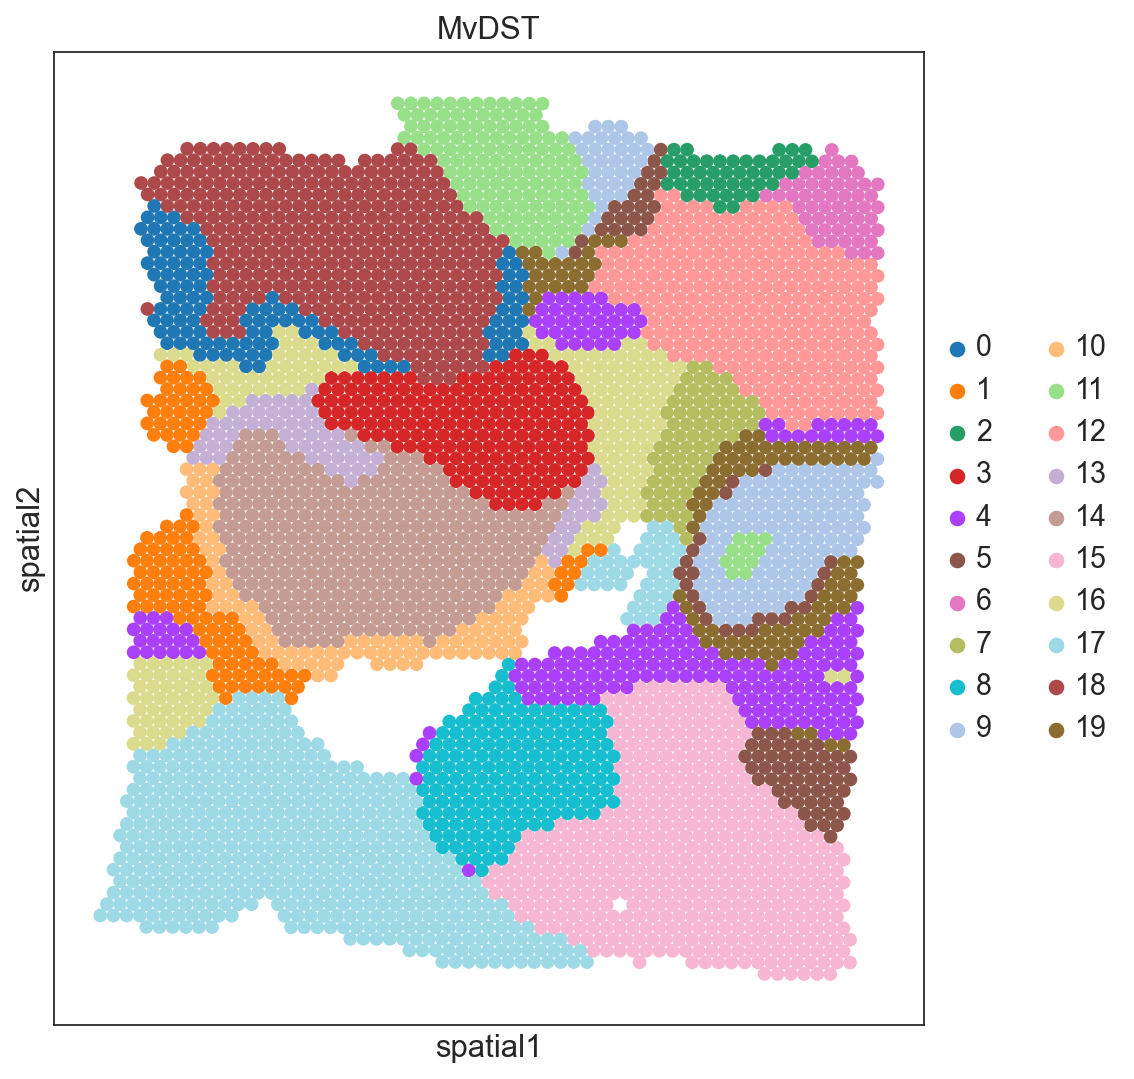

In [30]:
sc.pl.spatial(adata,color=['MvDST'], alpha_img=0, size=1.6)